In [332]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [333]:
pd.set_option('display.max_columns', None)
pd.set_option("display.max_rows", 100)

plt.style.use('ggplot')

In [334]:
df= pd.read_csv("/home/ahmed/Desktop/Data_Science/Projects/student-performance-prediction/data/student-mat.csv",sep=';')

In [335]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [336]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [337]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [338]:
df.shape


(395, 33)

In [339]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [340]:
df.duplicated().sum()  

np.int64(0)

In [341]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

print("Numerical Columns:", num_cols)
print("\nCategorical Columns:", cat_cols)

Numerical Columns: Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

Categorical Columns: Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


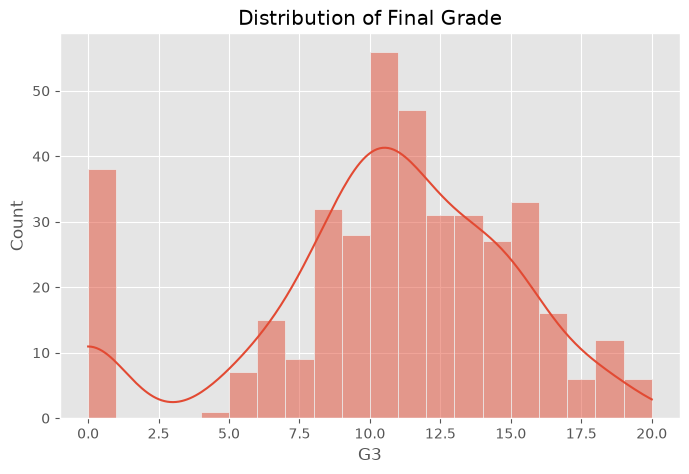

In [342]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Distribution of Final Grade")

plt.savefig("../images/g3_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

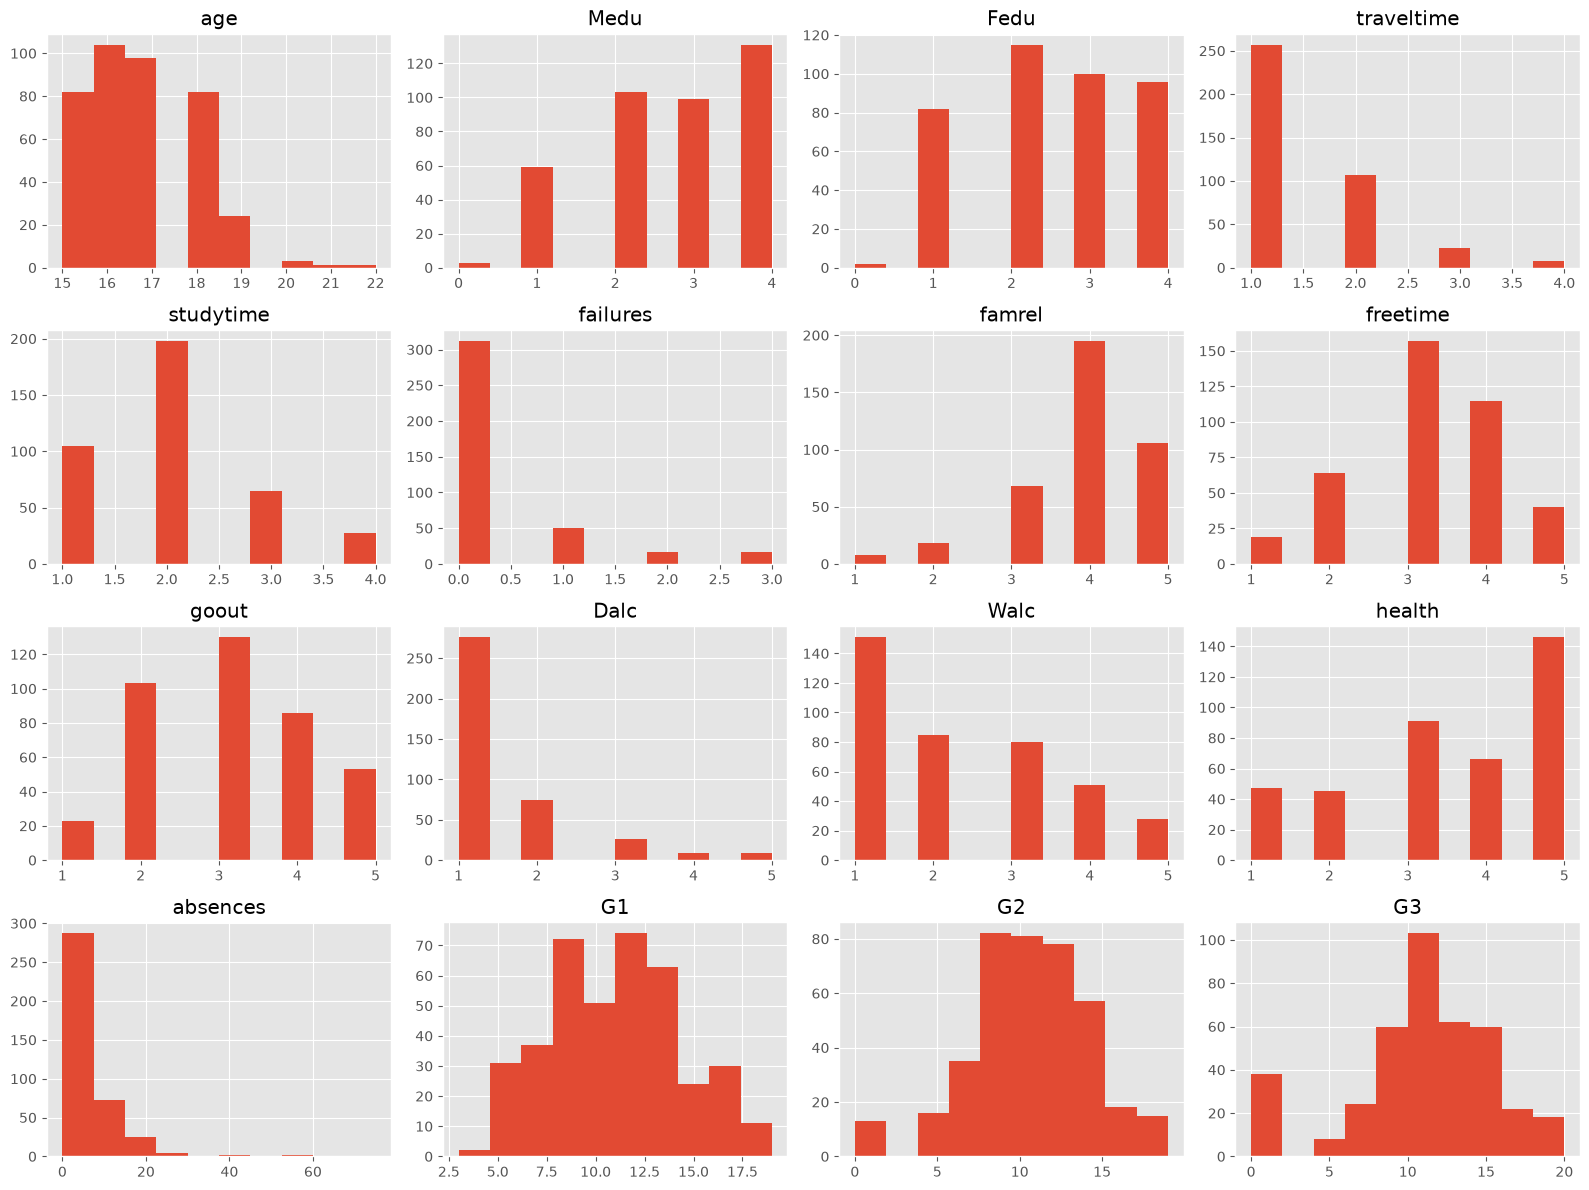

In [343]:
df[num_cols].hist(figsize=(16, 12))
plt.savefig("../images/numerical_features.png", dpi=300)


plt.tight_layout()
plt.show()

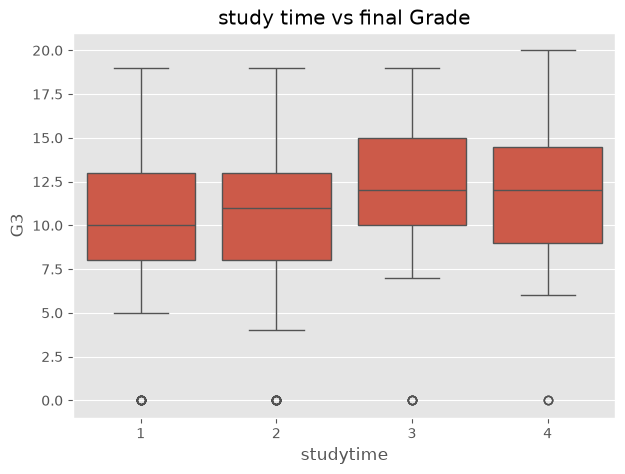

In [344]:
plt.figure(figsize=(7,5))

sns.boxplot(x= 'studytime' , y = "G3" , data = df )
plt.savefig("../images/studytime_vs_g3.png", dpi=300)


plt.title ("study time vs final Grade")
plt.show()

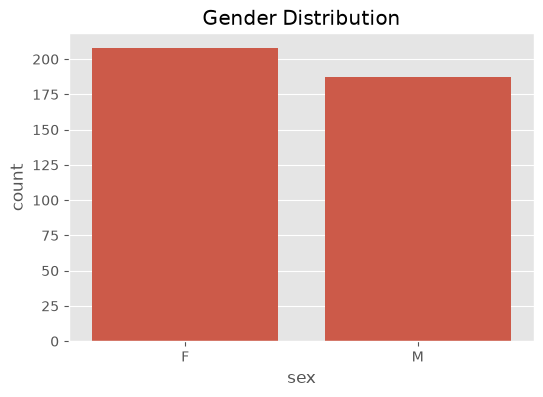

In [345]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="sex")

plt.title("Gender Distribution")

plt.savefig("../images/gender_distribution.png", dpi=300)

plt.show()

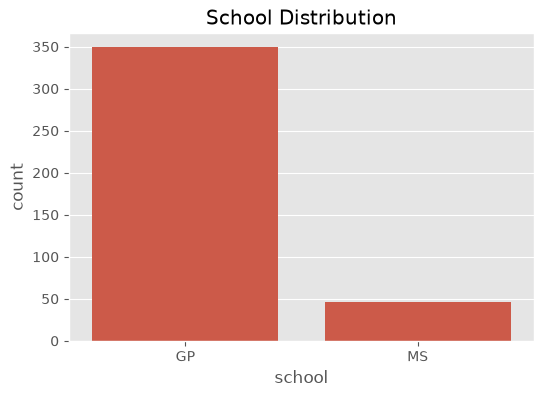

In [346]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="school")

plt.title("School Distribution")

plt.savefig("../images/school_distribution.png", dpi=300)

plt.show()

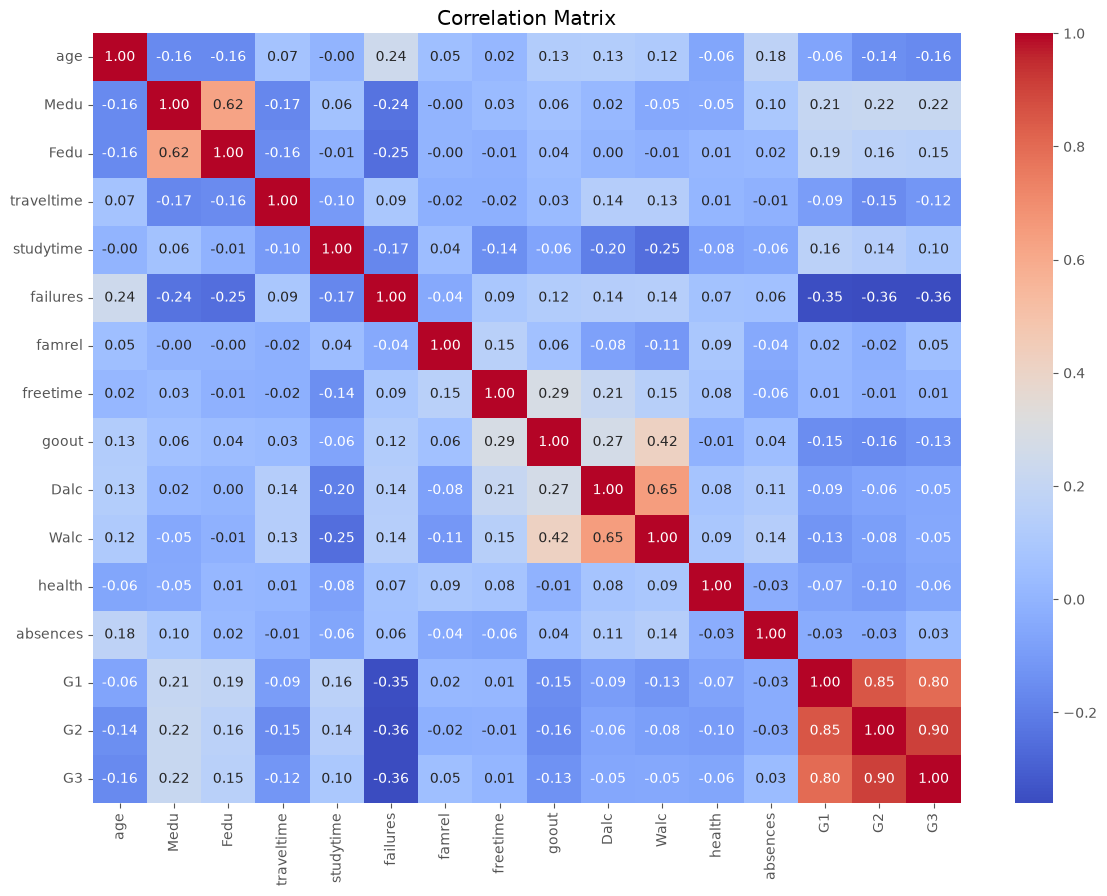

In [347]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

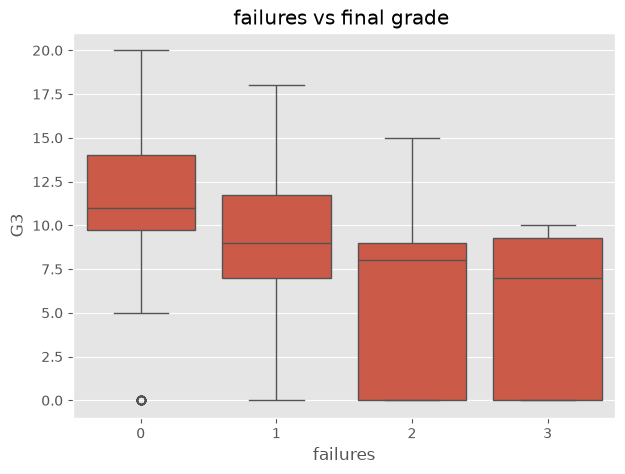

In [348]:
plt.figure(figsize=(7,5))

sns.boxplot (x= "failures" , y = "G3" , data = df )
plt.savefig("../images/failures_vs_g3.png", dpi=300)

plt.title("failures vs final grade ")
plt.show()

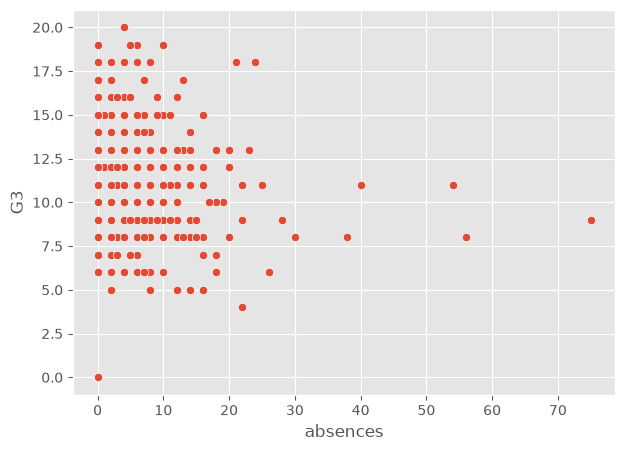

In [349]:
plt.figure(figsize=(7,5))
sns.scatterplot ( x = "absences" , y = "G3", data = df )
plt.savefig("../images/absences_vs_g3.png", dpi=300)

plt.show()

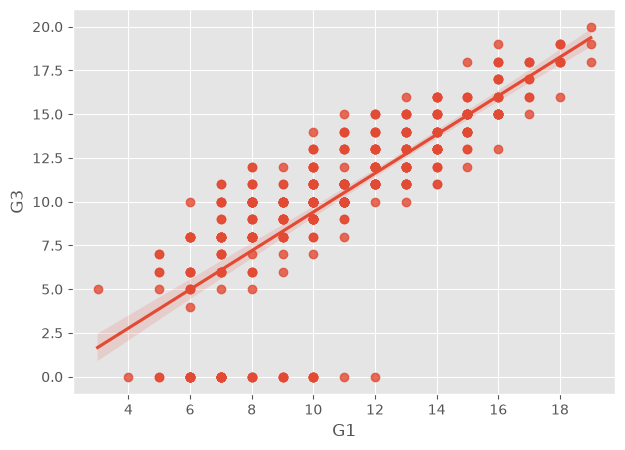

In [350]:
plt.figure(figsize=(7,5))

sns.regplot(
    data=df,
    x="G1",
    y="G3"
)
plt.savefig("../images/g1_vs_g3.png", dpi=300)


plt.show()

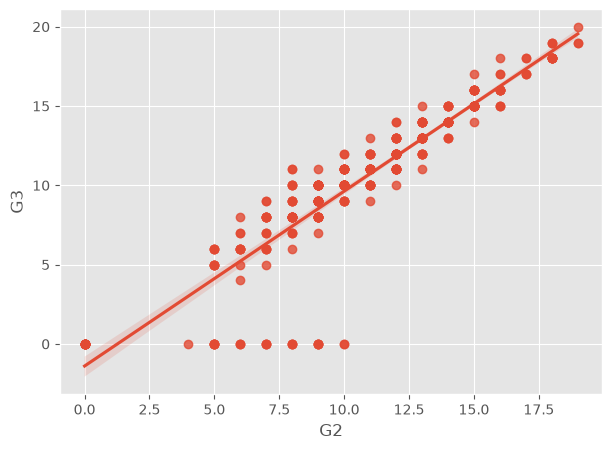

In [351]:
plt.figure(figsize=(7,5))

sns.regplot(
    data=df,
    x="G2",
    y="G3"
)
plt.savefig("../images/g2_vs_g3.png", dpi=300)


plt.show()

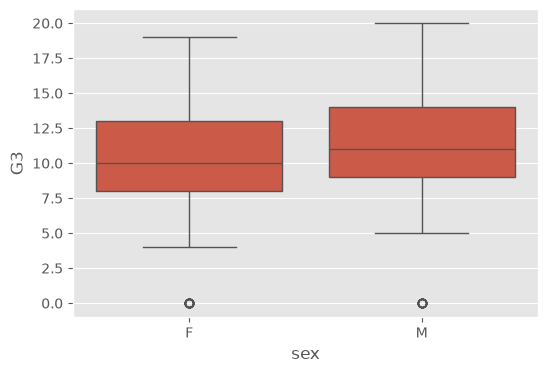

In [352]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="sex",
    y="G3"
)

plt.show()

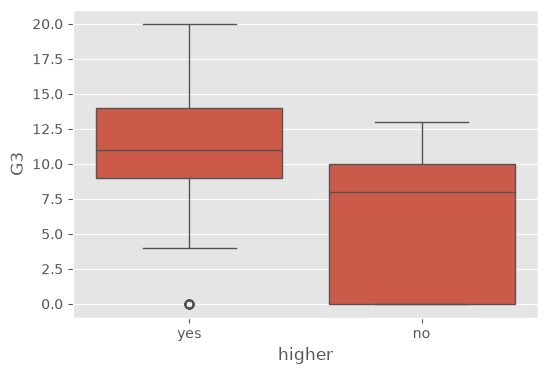

In [353]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="higher",
    y="G3"
)

plt.savefig("../images/higher_vs_g3.png", dpi=300)

plt.show()

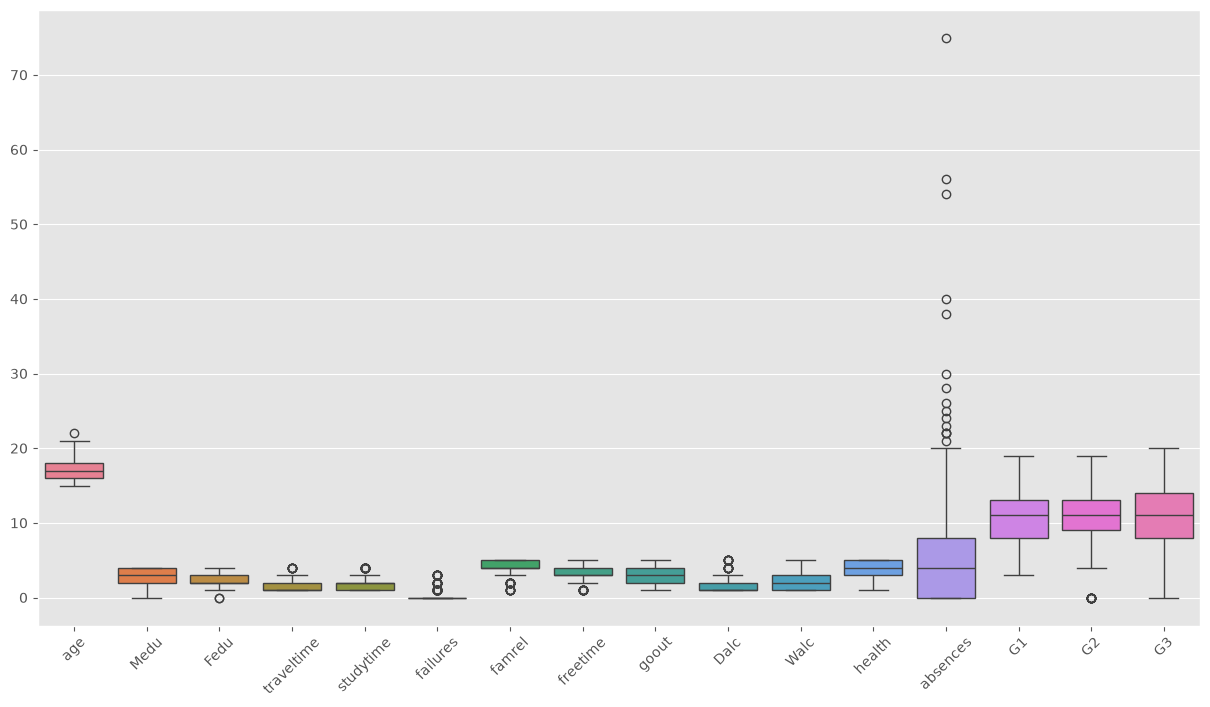

In [354]:
plt.figure(figsize=(15,8))
sns.boxplot(data = df [num_cols])

plt.xticks(rotation=45)
plt.savefig("../images/outliers.png", dpi=300, bbox_inches="tight")

plt.show()

In [355]:
x = df.drop("G3", axis=1)
y = df["G3"]

In [356]:
cat_cols = x.select_dtypes(include="object").columns
num_cols = x.select_dtypes(include=["int64", "float64"]).columns

print(cat_cols)
print(num_cols)



Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object')


In [357]:
from sklearn.preprocessing import OneHotEncoder
x = pd.get_dummies(x, columns=cat_cols, drop_first=True)


In [358]:
x.shape

(395, 41)

In [359]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [360]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [361]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](41,)","[-0.15, 0.09,-0.18,..., 0.09,-0.06,-0.19]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.33
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,41
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(41)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](41,)","[34.01,29.59,26.03,..., 6.27, 6.18, 4.86]"


In [362]:
y_pred = model.predict(x_test)


In [363]:
from sklearn.metrics import mean_absolute_error ,mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

MAE  : 1.65
MSE  : 5.66
RMSE : 2.38
R²   : 0.72


In [364]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)

lasso_pred = lasso.predict(x_test)

In [399]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=45,
    random_state=42
)

rf.fit(x_train,y_train)

rf_pred = rf.predict(x_test)

In [400]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 30)
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}")



evaluate_model("Linear Regression", y_test, y_pred)
evaluate_model("Lasso Regression", y_test, lasso_pred)
evaluate_model("Random Forest", y_test, rf_pred)




Linear Regression
------------------------------
MAE  : 1.65
MSE  : 5.66
RMSE : 2.38
R²   : 0.72

Lasso Regression
------------------------------
MAE  : 1.38
MSE  : 4.67
RMSE : 2.16
R²   : 0.77

Random Forest
------------------------------
MAE  : 1.19
MSE  : 3.67
RMSE : 1.92
R²   : 0.82


In [367]:
import joblib
joblib.dump(rf, "../models/random_forest_model.pkl") 
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [368]:
result = pd.DataFrame({
    "Actule":y_test,
    "Predicted":rf_pred
})
result.head(15)

,Actule,Predicted
78,10,8.32
371,12,11.76
248,5,6.54
55,10,9.77
390,9,8.80
223,13,12.84
42,18,18.70
234,6,6.71
316,0,6.68
116,14,13.36


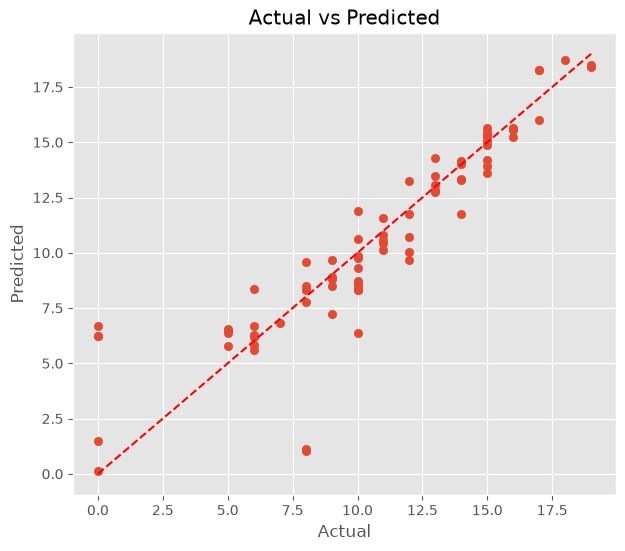

In [369]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.savefig("../images/actual_vs_predicted.png",
            dpi=300,
            bbox_inches="tight")

plt.show()